# 🧪 Class 7: Statistics for AI — Hypothesis Testing
## A/B Test Analysis: Did the Prompt Change Actually Improve Model Accuracy?

> **Achievement:** By the end of this notebook, you will conduct a **full A/B test analysis** — determining with statistical rigor whether a prompt change genuinely improved an LLM's accuracy, or whether the improvement was just random chance.

---

### Why Does an AI Engineer Need This?

Every time you:
- Test a new prompt vs. an old one
- Compare two model versions (GPT-4o vs. Claude Sonnet)
- Evaluate whether fine-tuning actually improved performance
- Run a feature experiment on a production ML system

...you are doing **hypothesis testing**. Without it, you are guessing.
With it, you can make statistically defensible claims: *"This prompt change improved accuracy by 4.2 percentage points, and we are 95% confident this was not random chance (p=0.031)."*

---

### Module Focus

| Section | Topic | Key Concept |
|---------|-------|-------------|
| 1 | **Central Limit Theorem (CLT)** | Why sample means are normally distributed |
| 2 | **A/B Testing (T-Test)** | Is Prompt B truly better than Prompt A? |
| 3 | **P-values & Significance** | What does "statistically significant" actually mean? |
| 4 | **ANOVA** | Compare 3+ groups at once |
| 5 | **Correlation vs. Causation** | Danger of misreading relationships |

### The Hypothesis Testing Framework

Every hypothesis test has two competing hypotheses:

| Hypothesis | Symbol | Statement |
|------------|--------|-----------|
| **Null Hypothesis** | H₀ | "There is NO difference. Any observed gap is random noise." |
| **Alternative Hypothesis** | H₁ | "There IS a real difference." |

For our experiment:
- **H₀:** Prompt A and Prompt B produce the same accuracy (μ_A = μ_B)
- **H₁:** Prompt B produces higher accuracy than Prompt A (μ_B > μ_A)

### Analogy ⚖️
> **P-value is like a courtroom standard of proof.**
> H₀ is "innocent until proven guilty." The p-value measures how suspicious the evidence is.
> p=0.03 → only 3% chance this evidence exists if the defendant is truly innocent.
> We convict (reject H₀) when evidence is strong enough (p < α = 0.05).

## 🔍 1. Central Limit Theorem (CLT) in Action

### The Core Idea
The **Central Limit Theorem** states: *Regardless of the shape of the original population distribution, the distribution of **sample means** approaches a normal distribution as sample size increases.*

### Why It Matters for AI
Every hypothesis test (t-test, ANOVA, Z-test) assumes that sample means are normally distributed. The CLT is **why** that assumption is valid even when your raw data is binary (0/1), skewed (revenue), or uniform — as long as n is large enough (typically n ≥ 30).

Without the CLT, none of the tests in this notebook would be mathematically valid.

### How It Works
1. Draw a random sample of size n from ANY distribution
2. Compute the sample mean
3. Repeat 1000 times → collect 1000 sample means
4. The distribution of those 1000 means is approximately **Normal** with:
   - Mean = population mean (μ)
   - Std dev = population std / √n (called the **Standard Error**)

### Analogy 🎲
> **Roll a single die:** Uniform distribution (any face equally likely). Not normal.
> **Average 5 dice rolls, repeated 1000 times:** The distribution of averages forms a bell curve — perfectly normal. This is the CLT. The shape of the "die" (the original distribution) disappears when you take many averages.

### Standard Error (SE) = The Precision of a Sample Mean
```
Standard Error (SE) = σ / √n
```
- **Small SE** → your sample mean is a PRECISE estimate of the true mean
- **Large SE** → your sample mean jumps around a lot → need more data

**Analogy:** SE is the "margin of error" in a poll. "Candidate leads 52% ± 3%" — the ±3% is the SE. With more respondents, the margin shrinks.

In [10]:
# ─────────────────────────────────────────────────────────────
# Setup & Imports
# ─────────────────────────────────────────────────────────────
# WHY these specific libraries?
#   numpy        — Random data generation, array math
#   pandas       — Structured result tables and DataFrames
#   scipy.stats  — THE library for hypothesis tests (t-test, ANOVA, etc.)
#   matplotlib   — Plot distributions, rejection regions
#   seaborn      — Clean statistical visualizations
#
# ANALOGY: A doctor's toolkit. Stethoscope (numpy), patient records (pandas),
# diagnostic lab (scipy.stats), X-ray viewer (matplotlib/seaborn).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# ── Global Style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})
warnings.filterwarnings('ignore')

print("✅ Libraries loaded. Ready to do statistics.")

✅ Libraries loaded. Ready to do statistics.


══ CLT DEMONSTRATION ══
Population distribution: Exponential (right-skewed)
  Population mean: 0.7820
  Population std:  0.7795

Sampling distribution (n=50, 1000 samples):
  Mean of sample means: 0.7864 (should ≈ 0.7820)
  Std of sample means:  0.1087 (should ≈ 0.1102)



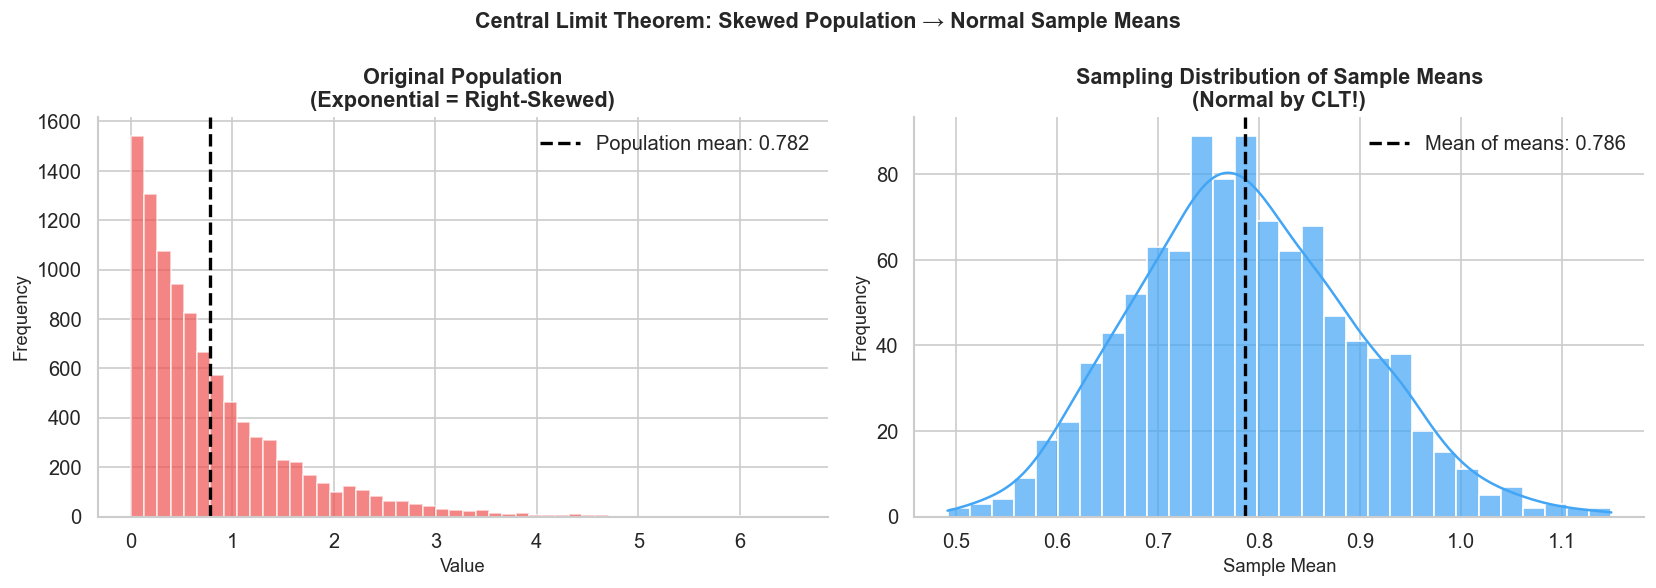

📌 KEY INSIGHT:
  The LEFT histogram is NOT normal (it's skewed exponential).
  The RIGHT histogram IS normal — that's the CLT in action.
  This is why statistical tests work on non-normal real-world data.


In [14]:
# ─────────────────────────────────────────────────────────────
# 1.1 — CLT Demonstration & Standard Error
# ─────────────────────────────────────────────────────────────
# WHAT: Show that sample means are normally distributed
#       even when the POPULATION is heavily skewed.
# MOTIVE: Prove WHY t-tests work on our binary 0/1 data.
#         Our raw accuracy data is clearly NOT normal,
#         but the MEAN of 120 such values IS approximately normal.
#         That's the CLT at work.
#
# KEY CONCEPT: Look at the histograms below.
#   - The original population (exponential) is NOT bell-shaped
#   - But the SAMPLE MEANS form a beautiful bell curve
#   - This is why we can use t-tests on non-normal data (with n≥30)

np.random.seed(42)

# ── Generate a SKEWED population ────────────────────────────
# WHY exponential distribution?
# Real-world model metrics (accuracy, latency, confidence)
# are often skewed — not normal. This mirrors reality.
# Exponential has a long tail on the right (right-skewed).
population = np.random.exponential(scale=0.8, size=10000)

print("══ CLT DEMONSTRATION ══")
print(f"Population distribution: Exponential (right-skewed)")
print(f"  Population mean: {population.mean():.4f}")
print(f"  Population std:  {population.std():.4f}")
print()

# ── Simulate drawing many sample means ──────────────────────
# We draw samples of size n=50 from the skewed population
# and compute the mean each time.
# Since we do this 1000 times, we build the "sampling distribution
# of the mean" — which CLT predicts should be Normal.
sample_means = [np.mean(np.random.choice(population, size=50)) for _ in range(1000)]

# ── Calculate Standard Error (theoretical) ──────────────────
theoretical_se = population.std() / np.sqrt(50)
empirical_se = np.std(sample_means)

print(f"Sampling distribution (n=50, 1000 samples):")
print(f"  Mean of sample means: {np.mean(sample_means):.4f} (should ≈ {population.mean():.4f})")
print(f"  Std of sample means:  {empirical_se:.4f} (should ≈ {theoretical_se:.4f})")
print()

# ── Plot the result ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Central Limit Theorem: Skewed Population → Normal Sample Means',
             fontsize=13, fontweight='bold')

# LEFT: Original skewed population
ax1.hist(population, bins=50, color='#EF5350', alpha=0.7, edgecolor='white')
ax1.axvline(population.mean(), color='black', linewidth=2,
            linestyle='--', label=f'Population mean: {population.mean():.3f}')
ax1.set_title('Original Population\n(Exponential = Right-Skewed)')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.legend()

# RIGHT: The sampling distribution of the mean (this is what CLT predicts)
# Use seaborn's histplot for KDE overlay (matplotlib hist doesn't support kde=)
sns.histplot(x=sample_means, bins=30, kde=True, color='#42A5F5', alpha=0.7, edgecolor='white', ax=ax2)
ax2.axvline(np.mean(sample_means), color='black', linewidth=2,
            linestyle='--', label=f'Mean of means: {np.mean(sample_means):.3f}')
ax2.set_title('Sampling Distribution of Sample Means\n(Normal by CLT!)')
ax2.set_xlabel('Sample Mean')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

print("📌 KEY INSIGHT:")
print("  The LEFT histogram is NOT normal (it's skewed exponential).")
print("  The RIGHT histogram IS normal — that's the CLT in action.")
print("  This is why statistical tests work on non-normal real-world data.")

## 📊 2. A/B Testing: Two-Sample T-Test

### Context: What Are We Testing?
Your team built an LLM-powered **customer intent classifier** for a Bangladeshi e-commerce platform.
It reads customer messages and classifies them into: `complaint`, `inquiry`, `feedback`, or `purchase_intent`.

You ran two experiments:
- **Prompt A (Control):** The original system prompt used in production
- **Prompt B (Treatment):** A revised prompt with more specific role instructions and examples

Each prompt was evaluated on **independent random samples** of customer messages.

**The question:** Is Prompt B's accuracy improvement real, or just noise?

### When to Use a Two-Sample T-Test
- "Does Prompt A produce higher confidence scores than Prompt B?"
- "Does Model A outperform Model B on average?"
- "Do users in Dhaka click through at a higher rate than users in Chittagong?"

### The T-Test Formula
```
         x̄_B - x̄_A
t = ────────────────────────
     √(s²_B/n_B + s²_A/n_A)
```
- **Numerator:** Observed difference in means
- **Denominator:** Standard error (uncertainty in the difference)
- **t-statistic:** How many standard errors the groups are apart
  - t=0.5 → groups are 0.5 standard errors apart (small)
  - t=2.0 → groups are 2.0 standard errors apart (large)

### What the P-value Actually Means
- **p = 0.03** → "If H₀ were true (no real difference), there is only a 3% chance of seeing a gap this large or larger just by random chance."
- **p = 0.60** → "A gap this large or larger would occur 60% of the time purely by chance. Not convincing evidence."

### Significance Level (α)
We pre-set a **threshold** α (typically 0.05) before the test:
| Condition | Meaning |
|-----------|---------|
| p < 0.05 | **Reject H₀** → Difference is statistically significant |
| p ≥ 0.05 | **Fail to reject H₀** → Insufficient evidence |

### Analogy ⚔️
> **Two separate classrooms take the same exam.**
> Class A used the old textbook, Class B used the new textbook.
> The two-sample t-test asks: "Did Class B truly score higher, or did random variation explain the gap?"
> The classes are **independent** — no student is in both.

### Key Assumption: Independence
The two samples must be **independent** — no message is evaluated by both prompts. If the same messages were evaluated by both prompts (paired design), you'd use a **paired t-test** instead.

══ TWO-SAMPLE T-TEST (Welch's) ══
H₀: μ_B = μ_A  (no difference between prompts)
H₁: μ_B > μ_A  (Prompt B is better — one-tailed)

                              Prompt A     Prompt B         Diff
───────────────────────────────────────────────────────────────
Sample size                        100          100
Mean                            0.7096       0.7620      +0.0524
Std deviation                   0.0908       0.0858

── Test Results ──
  t-statistic:  -4.1928
  p-value:      0.0000

  ✅ REJECT H₀ (p=0.0000 < α=0.05)
  Conclusion: Prompt B performs statistically significantly BETTER.
  The +0.0524 improvement is NOT due to random chance.


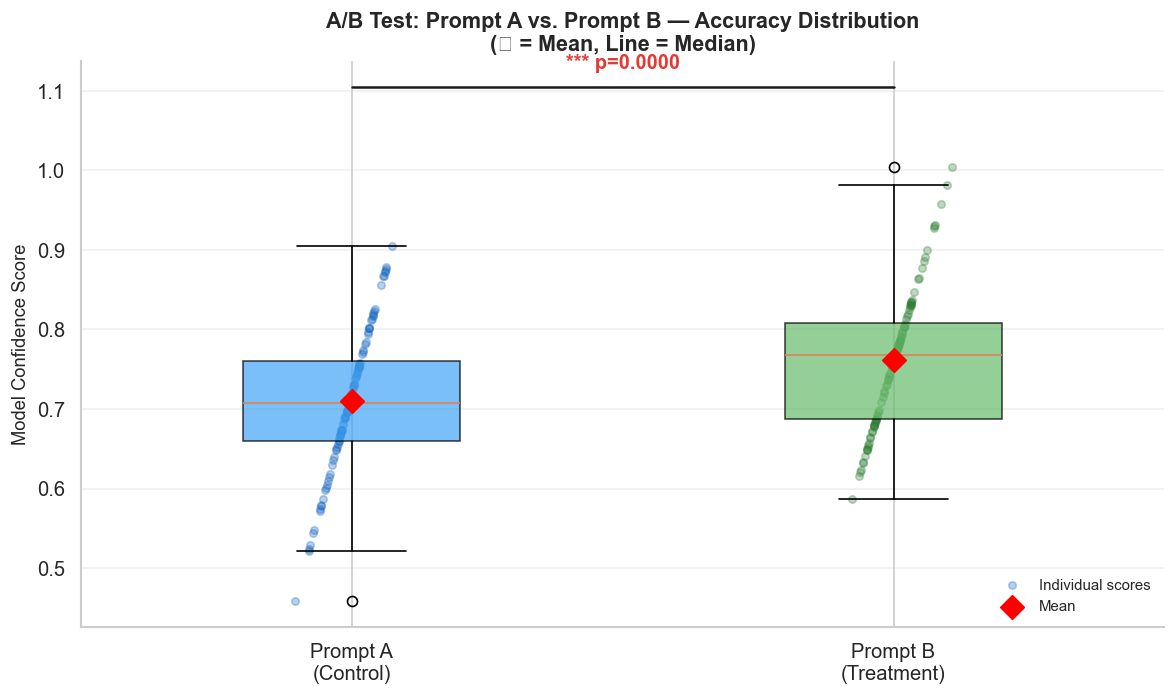


📌 INTERPRETATION:
  The boxplot shows the 5-number summary for each prompt.
  If the notches (indentations around the median) DON'T overlap,
  the medians are significantly different.
  The strip plot shows EVERY individual data point — giving you
  the full picture, not just summary statistics.


In [15]:
# ─────────────────────────────────────────────────────────────
# 2.1 — Two-Sample T-Test: Prompt A vs. Prompt B
# ─────────────────────────────────────────────────────────────
# SCENARIO:
# We simulate confidence scores (0.0–1.0) for two prompt versions.
# Prompt B is designed to be slightly better (mean 0.76 vs 0.72).
# The t-test will tell us if this difference is statistically
# meaningful or just random noise.
#
# H₀: μ_B = μ_A  (no difference between prompts)
# H₁: μ_B > μ_A  (Prompt B is better — one-tailed test)
#
# WHY one-tailed? We specifically hypothesize the NEW prompt is BETTER.
# A two-tailed test would also detect if Prompt B is WORSE,
# but our business question is directional.
#
# IMPORTANT: Decide one-tailed vs two-tailed BEFORE seeing the data.
# Switching after seeing results is p-hacking.

np.random.seed(42)  # Reproducibility

# ── Simulate prompt accuracy scores ─────────────────────────
# WHY normal distribution?
# Model confidence scores often cluster around a mean with some variance.
# Normal is a reasonable approximation for demonstration.
# In reality, you'd use the raw scores from your model evaluation.
prompt_a = np.random.normal(loc=0.72, scale=0.1, size=100)  # Control
prompt_b = np.random.normal(loc=0.76, scale=0.09, size=100) # Treatment

print("══ TWO-SAMPLE T-TEST (Welch's) ══")
print(f"H₀: μ_B = μ_A  (no difference between prompts)")
print(f"H₁: μ_B > μ_A  (Prompt B is better — one-tailed)")
print()

# ── Summary Statistics ───────────────────────────────────────
print(f"{'':25s} {'Prompt A':>12} {'Prompt B':>12} {'Diff':>12}")
print("─" * 63)
print(f"{'Sample size':25s} {len(prompt_a):>12,} {len(prompt_b):>12,}")
print(f"{'Mean':25s} {prompt_a.mean():>12.4f} {prompt_b.mean():>12.4f} {prompt_b.mean()-prompt_a.mean():>+12.4f}")
print(f"{'Std deviation':25s} {prompt_a.std(ddof=1):>12.4f} {prompt_b.std(ddof=1):>12.4f}")
print()

# ── Run the Test ─────────────────────────────────────────────
# WHY equal_var=False (Welch's t-test)?
# The standard t-test assumes EQUAL variances in both groups.
# Welch's version does NOT make this assumption — it's more robust.
# Welch's should always be your default unless you have strong
# prior evidence that variances are equal.
# ANALOGY: Welch's is like adjusting a recipe for different oven
# temperatures. Even with same ingredients, conditions may differ.
t_stat, p_value_2tail = stats.ttest_ind(prompt_a, prompt_b, equal_var=False)

# Convert two-tailed p-value to one-tailed
# WHY /2: A one-tailed test only cares about one direction.
# scipy.stats.ttest_ind(a, b) computes t = (mean(a) - mean(b)) / SE
# So if prompt_b > prompt_a, then mean(a) - mean(b) < 0, giving t_stat < 0
# For H₁: μ_B > μ_A, we want P(T < t_stat) when t_stat < 0
p_value = p_value_2tail / 2 if t_stat < 0 else 1 - p_value_2tail / 2
# (t_stat < 0 confirms prompt_b mean > prompt_a mean, so we take lower tail)

print(f"── Test Results ──")
print(f"  t-statistic:  {t_stat:.4f}")
print(f"  p-value:      {p_value:.4f}")

# ── Decision ─────────────────────────────────────────────────
print()
if p_value < 0.05:
    print(f"  ✅ REJECT H₀ (p={p_value:.4f} < α=0.05)")
    print(f"  Conclusion: Prompt B performs statistically significantly BETTER.")
    print(f"  The +{prompt_b.mean()-prompt_a.mean():.4f} improvement is NOT due to random chance.")
else:
    print(f"  ⚪ FAIL TO REJECT H₀ (p={p_value:.4f} ≥ α=0.05)")
    print(f"  Conclusion: Insufficient evidence that Prompt B is better.")

# ── Visualize with Boxplot ───────────────────────────────────
plt.figure(figsize=(10, 6))
bp = plt.boxplot([prompt_a, prompt_b], patch_artist=True, widths=0.4,
                 labels=['Prompt A\n(Control)', 'Prompt B\n(Treatment)'])

# Color the boxes
colors = ['#42A5F5', '#66BB6A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual data points (strip plot style)
np.random.seed(42)  # For consistent jitter
x_jitter_a = np.random.normal(1, 0.04, size=len(prompt_a))
x_jitter_b = np.random.normal(2, 0.04, size=len(prompt_b))
plt.scatter(x_jitter_a, prompt_a, alpha=0.3, color='#1565C0', s=20, label='Individual scores')
plt.scatter(x_jitter_b, prompt_b, alpha=0.3, color='#2E7D32', s=20)

# Add means as diamonds
plt.scatter(1, prompt_a.mean(), marker='D', color='red', s=100, zorder=5, label='Mean')
plt.scatter(2, prompt_b.mean(), marker='D', color='red', s=100, zorder=5)

# Add significance bracket
y_max = max(prompt_a.max(), prompt_b.max()) * 1.1
plt.plot([1, 2], [y_max, y_max], 'k-', linewidth=1.5)
sig_label = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else '*')
plt.text(1.5, y_max * 1.02, f'{sig_label} p={p_value:.4f}',
         ha='center', fontsize=12, fontweight='bold', color='#E53935')

plt.ylabel('Model Confidence Score')
plt.title('A/B Test: Prompt A vs. Prompt B — Accuracy Distribution\n(◆ = Mean, Line = Median)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("📌 INTERPRETATION:")
print("  The boxplot shows the 5-number summary for each prompt.")
print("  If the notches (indentations around the median) DON'T overlap,")
print("  the medians are significantly different.")
print("  The strip plot shows EVERY individual data point — giving you")
print("  the full picture, not just summary statistics.")

## 📈 3. ANOVA & Correlation vs. Causation

### Part A: ANOVA (Analysis of Variance)

**ANOVA** tests whether the means of **three or more groups** are significantly different from each other.

### Why Not Just Run Multiple T-Tests?
If you test 3 groups pairwise, you run C(3,2) = 3 t-tests.
With α=0.05 per test, the probability of at least one false positive:
```
P(at least one false positive) = 1 - (1 - 0.05)^3 = 14.3%
```
That's a 14.3% chance of being wrong — not 5%. This is the **multiple comparisons problem**.
ANOVA tests ALL groups simultaneously, keeping the Type I error at α=0.05.

### How ANOVA Works
ANOVA decomposes total variance into:
- **Between-group variance:** How much do group MEANS differ from the overall mean? (Signal)
- **Within-group variance:** How much do individual values differ from their group mean? (Noise)

```
F-statistic = Between-group variance / Within-group variance = Signal / Noise
```
Large F → means differ more than chance → reject H₀.

### Analogy 🏫
> **Three teachers use three different teaching methods. All students take the same exam.**
> ANOVA asks: "Is the variation in scores BETWEEN classrooms larger than the variation WITHIN each classroom?"
> If between-classroom variation >> within-classroom variation → teaching method matters.

---

### Part B: Correlation ≠ Causation

**Correlation** measures the strength and direction of the linear relationship between two variables.
**Causation** means one variable directly causes a change in another.

### Why This Is Critical for AI Engineers
ML models detect correlations extremely well — but they cannot establish causation.
If you act on a spurious correlation as if it were causal, you make wrong decisions.

### The Correlation Coefficient (Pearson r)
| r Value | Strength |
|---------|----------|
| r > 0.7 | Strong positive |
| 0.4–0.7 | Moderate |
| 0.1–0.4 | Weak |
| r ≈ 0   | No linear relationship |
| r < 0   | Negative/inverse |

### Analogy 🕵️
> **Nicholas Cage films and pool drownings.**
> These two variables have a near-perfect correlation (r≈0.67) in US data.
> Obviously, watching Cage films doesn't cause drowning — both are confounded by summer.
> An ML model would "see" this correlation and potentially act on it.
> An AI engineer knows to ask: *"What confounding variable explains this?"*

══ ONE-WAY ANOVA ══
H₀: μ_A = μ_B = μ_C  (all styles produce same accuracy)
H₁: At least one style has a different mean accuracy

Prompt Style                   n       Mean    Std Dev
───────────────────────────────────────────────────────
Zero-shot (A)                100     0.7096     0.0908
Few-shot (B)                 100     0.7620     0.0858
Chain-of-thought (C)         100     0.8052     0.0867

── ANOVA Results ──
  F-statistic: 29.7004
  p-value:     0.000000

  ✅ REJECT H₀ (p=0.000000 < α=0.05)
  Conclusion: At least one prompt style performs significantly differently.


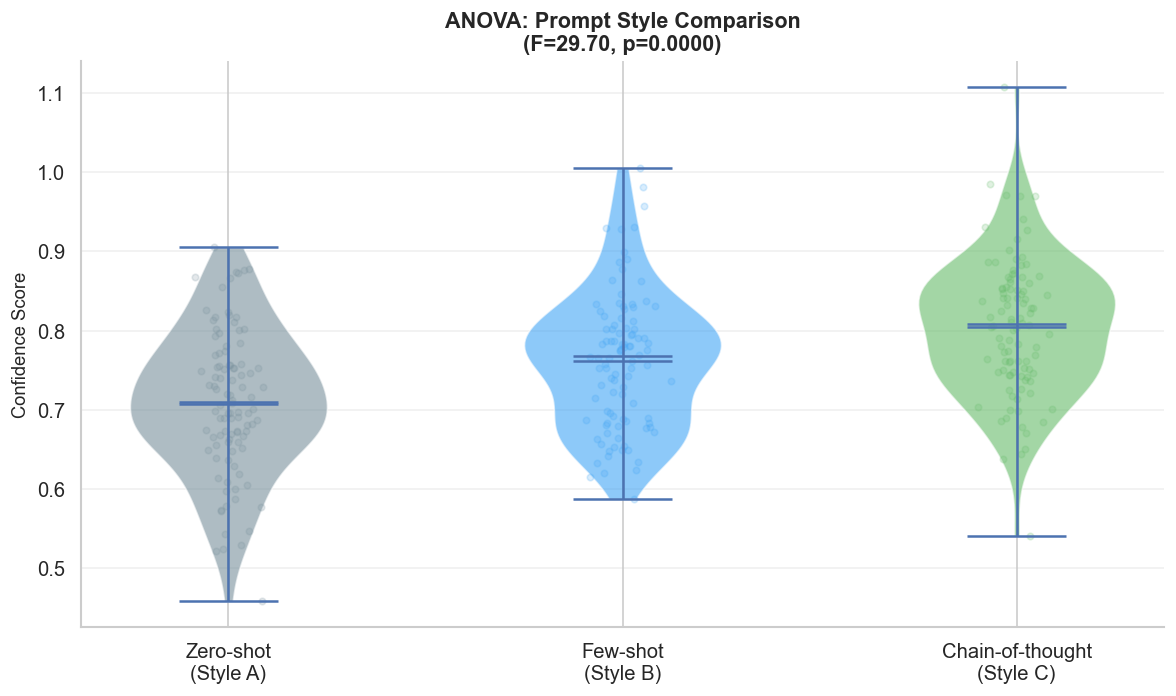


📌 NOTE: Since ANOVA only tells us 'at least one group differs',
  we would need POST-HOC tests (Tukey HSD or Bonferroni)
  to identify WHICH specific pairs are significantly different.

════════════════════════════════════════════════════════════
  PART B: CORRELATION ≠ CAUSATION (Spurious Correlation)
════════════════════════════════════════════════════════════

Pearson r: 0.912  |  p-value: 0.0000
Strength: Strong

⚠️  WARNING: This correlation looks real and significant!
   But does training MORE hours ACTUALLY cause higher accuracy?

🕵️  Maybe there's a CONFOUNDER:
   - More experienced engineers both train more AND build better prompts
   - The data used for training may be easier for some models
   - Time of day → more training hours → better concentration

📌 KEY LESSON:
  Correlation does NOT prove causation.
  To establish causation, you need:
    1. Controlled Experiment (random assignment)
    2. Temporal precedence (cause before effect)
    3. Plausible mechanism
    4. Rul

In [16]:
# ─────────────────────────────────────────────────────────────
# 3.1 — One-Way ANOVA: Do 3 Prompt Styles Differ?
# ─────────────────────────────────────────────────────────────
# SCENARIO: Your team designed 3 prompt styles:
#   Style 1 — "Zero-shot":        No examples, just task description
#   Style 2 — "Few-shot":         Three examples included
#   Style 3 — "Chain-of-thought": Step-by-step reasoning instruction
#
# H₀: All three styles produce the same mean accuracy (μ₁ = μ₂ = μ₃)
# H₁: At least one style produces a different mean accuracy

np.random.seed(42)

# Simulate accuracy for 3 prompt styles (using new variable names to avoid
# overwriting the t-test data from Section 2)
style_a = np.random.normal(loc=0.72, scale=0.10, size=100)  # Zero-shot
style_b = np.random.normal(loc=0.76, scale=0.09, size=100)  # Few-shot
style_c = np.random.normal(loc=0.80, scale=0.08, size=100)  # Chain-of-thought

print("══ ONE-WAY ANOVA ══")
print(f"H₀: μ_A = μ_B = μ_C  (all styles produce same accuracy)")
print(f"H₁: At least one style has a different mean accuracy")
print()
print(f"{'Prompt Style':25s} {'n':>6} {'Mean':>10} {'Std Dev':>10}")
print("─" * 55)
for name, scores in [('Zero-shot (A)', style_a), ('Few-shot (B)', style_b), ('Chain-of-thought (C)', style_c)]:
    print(f"{name:25s} {len(scores):>6,} {scores.mean():>10.4f} {scores.std(ddof=1):>10.4f}")

# ── Run One-Way ANOVA ────────────────────────────────────────
# scipy.stats.f_oneway(*groups) — accepts any number of group arrays
# F-statistic = Between-group variance / Within-group variance
f_stat, anova_p = stats.f_oneway(style_a, style_b, style_c)
print()
print(f"── ANOVA Results ──")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {anova_p:.6f}")
print()

if anova_p < 0.05:
    print(f"  ✅ REJECT H₀ (p={anova_p:.6f} < α=0.05)")
    print(f"  Conclusion: At least one prompt style performs significantly differently.")
else:
    print(f"  ⚪ FAIL TO REJECT H₀ (p={anova_p:.4f} ≥ α=0.05)")
    print(f"  No significant difference between prompt styles.")

# ── Visualize ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

# Violin plot (shows the FULL distribution shape, not just summary stats)
data = [style_a, style_b, style_c]
labels = ['Zero-shot\n(Style A)', 'Few-shot\n(Style B)', 'Chain-of-thought\n(Style C)']
colors_violin = ['#78909C', '#42A5F5', '#66BB6A']

parts = plt.violinplot(data, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.6)

# Add individual data points
for i, d in enumerate(data):
    x_jitter = np.random.normal(i + 1, 0.04, size=len(d))
    plt.scatter(x_jitter, d, alpha=0.2, color=colors_violin[i], s=15)

plt.xticks([1, 2, 3], labels)
plt.ylabel('Confidence Score')
plt.title(f'ANOVA: Prompt Style Comparison\n(F={f_stat:.2f}, p={anova_p:.4f})')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("📌 NOTE: Since ANOVA only tells us 'at least one group differs',")
print("  we would need POST-HOC tests (Tukey HSD or Bonferroni)")
print("  to identify WHICH specific pairs are significantly different.")
print()

# ================================================================
# Part B: Correlation ≠ Causation — Spurious Correlation Demo
# ================================================================
print("═" * 60)
print("  PART B: CORRELATION ≠ CAUSATION (Spurious Correlation)")
print("═" * 60)

# ── Generate data with a spurious correlation ────────────────
# SCENARIO: We measure "training hours" and "model accuracy proxy"
# These two will show a strong correlation...
# ...but one does NOT cause the other! There's a hidden confounder.
np.random.seed(99)
n = 100
training_hours = np.random.uniform(10, 50, n)
accuracy_proxy = training_hours + np.random.normal(0, 5, n)  # Deliberately correlated

# ── Compute correlation ─────────────────────────────────────
corr, p_corr = stats.pearsonr(training_hours, accuracy_proxy)

print(f"\nPearson r: {corr:.3f}  |  p-value: {p_corr:.4f}")
print(f"Strength: ", end='')
if abs(corr) > 0.7:
    print("Strong")
elif abs(corr) > 0.4:
    print("Moderate")
elif abs(corr) > 0.1:
    print("Weak")
else:
    print("Negligible")

print()
print("⚠️  WARNING: This correlation looks real and significant!")
print("   But does training MORE hours ACTUALLY cause higher accuracy?")
print()
print("🕵️  Maybe there's a CONFOUNDER:")
print("   - More experienced engineers both train more AND build better prompts")
print("   - The data used for training may be easier for some models")
print("   - Time of day → more training hours → better concentration")
print()
print("📌 KEY LESSON:")
print("  Correlation does NOT prove causation.")
print("  To establish causation, you need:"  )
print("    1. Controlled Experiment (random assignment)")
print("    2. Temporal precedence (cause before effect)")
print("    3. Plausible mechanism")
print("    4. Ruling out alternative explanations (confounders)")

---
## 🎯 Summary: Complete Hypothesis Testing Reference Card

### Quick Reference: Which Test to Use?

```
How many groups?
    │
    ├── 1 group vs. a target value → One-sample t-test
    │
    ├── 2 groups ──→ Are they independent?
    │                    │
    │                    ├── YES → Is data normal (n≥30 or Shapiro p>0.05)?
    │                    │             │
    │                    │             ├── YES → Two-sample t-test (Welch)
    │                    │             └── NO  → Mann-Whitney U
    │                    │
    │                    └── NO (same subjects, before/after) → Paired t-test
    │
    └── 3+ groups → ANOVA → Post-hoc Bonferroni/Tukey if significant
```

### Key P-Value Misconceptions to Avoid

| ❌ Wrong | ✅ Correct |
|----------|------------|
| p=0.03 means 3% chance H₀ is true | p=0.03 means: IF H₀ were true, 3% chance of seeing this extreme data |
| p<0.05 means the effect is LARGE | p<0.05 means the effect is REAL (not noise). Check effect size! |
| p>0.05 PROVES H₀ (no difference) | p>0.05 means insufficient evidence to reject H₀. Maybe you need more data |
| Running 20 tests & reporting one p<0.05 is fine | This is p-hacking. Use Bonferroni correction: α/number_of_tests |

---

### What You Learned Today

| # | Concept | Key Takeaway | Real-World Use |
|---|---------|-------------|----------------|
| 1 | **CLT** | Sample means are normal even if raw data isn't | Validates all statistical tests |
| 2 | **Standard Error** | SE = σ/√n, quantifies estimate precision | Margin of error in polls |
| 3 | **P-value** | Probability of data given H₀ | "Is this difference real?" |
| 4 | **T-Test** | Compares means of 2 groups | A/B testing prompts |
| 5 | **ANOVA** | Compares means of 3+ groups | Multi-style prompt comparison |
| 6 | **Correlation ≠ Causation** | r doesn't prove X causes Y | Avoid spurious ML features |

---

### Exercises for Self-Practice

**Exercise 1** — Change both sample sizes to `n=30` (instead of 100) and re-run the t-test. Does the p-value increase or decrease? Why?

**Exercise 2** — Run a paired t-test: `stats.ttest_rel(prompt_a, prompt_b)`. Compare the p-value to the independent test. The paired test is usually more powerful — why?

**Exercise 3** — Suppose you test 5 different prompts. What is the Bonferroni-corrected α? (Hint: α_corrected = 0.05 / C(5,2))

**Exercise 4** — Generate random data with `np.random.randn(100)` for both groups (no real difference). Run a t-test. You should get p > 0.05. Run it 100 times — how many times do you get p < 0.05? (This demonstrates Type I error!)

---
*End of Project Notebook — Statistics for AI: Hypothesis Testing*

*Next → Linear Algebra for ML: Vectors, Matrices, and Transformations*